In [1]:
"""
# 11. Feature Extraction vs Fine-Tuning con MobileNetV2

## Objetivos
- Entender la diferencia conceptual entre "feature extraction" y "fine-tuning"
- Cargar el modelo entrenado en el notebook 10 (feature extraction, 86.5%)
- Aplicar fine-tuning sobre MobileNetV2 y comparar resultados
- Analizar el trade-off entre costo computacional y ganancia de accuracy

## Conceptos clave
| Estrategia | Capas base | Capas superiores | Uso típico |
|---|---|---|---|
| Feature Extraction | ❄️ Congeladas | 🔥 Entrenables | Dataset pequeño / muy diferente al original |
| Fine-Tuning | 🔥 Parcialmente descongeladas | 🔥 Entrenables | Dataset mediano / similar al original |

> "Prerequisito:" "10_mobilenetv2_feature_extraction.keras" — MobileNetV2 sobre CIFAR-10
## ¿Por qué hacer fine-tuning?

En "feature extraction", usamos MobileNetV2 como un extractor fijo:
las capas convolucionales aprenden features genéricas (bordes, texturas, formas)
entrenadas sobre ImageNet — y solo entrenamos un clasificador encima.

El problema: esas features fueron optimizadas para ImageNet (224×224, 1000 clases).
CIFAR-10 es muy diferente (32×32, objetos simples). Las capas más profundas
de la red aprenden features "demasiado específicas" para ImageNet.

"Fine-tuning" soluciona esto: descongelamos las últimas capas de la base
y las re-entrenamos con un "learning rate muy bajo" para que se adapten
a nuestro dominio sin destruir el conocimiento previo.

### Regla práctica
- LR fine-tuning ≈ 10x–100x menor que el LR de entrenamiento inicial
- Descongelar gradualmente (de arriba hacia abajo)
- Siempre hacer fine-tuning "después" de converger con feature extraction
"""

'\n# 11. Feature Extraction vs Fine-Tuning con MobileNetV2\n\n## Objetivos\n- Entender la diferencia conceptual entre "feature extraction" y "fine-tuning"\n- Cargar el modelo entrenado en el notebook 10 (feature extraction, 86.5%)\n- Aplicar fine-tuning sobre MobileNetV2 y comparar resultados\n- Analizar el trade-off entre costo computacional y ganancia de accuracy\n\n## Conceptos clave\n| Estrategia | Capas base | Capas superiores | Uso típico |\n|---|---|---|---|\n| Feature Extraction | ❄️ Congeladas | 🔥 Entrenables | Dataset pequeño / muy diferente al original |\n| Fine-Tuning | 🔥 Parcialmente descongeladas | 🔥 Entrenables | Dataset mediano / similar al original |\n\n> "Prerequisito:" "10_mobilenetv2_feature_extraction.keras" — MobileNetV2 sobre CIFAR-10\n## ¿Por qué hacer fine-tuning?\n\nEn "feature extraction", usamos MobileNetV2 como un extractor fijo:\nlas capas convolucionales aprenden features genéricas (bordes, texturas, formas)\nentrenadas sobre ImageNet — y solo entrenamos 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")
print(f"GPU disponible:     {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
Keras version:      3.14.0
GPU disponible:     False


In [3]:
# Cargamos CIFAR-10 (mismo pipeline que notebook 10)
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Normalización [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Separamos validación
x_val = x_train[-5000:]
y_val = y_train[-5000:]
x_train = x_train[:-5000]
y_train = y_train[:-5000]

print(f"Train:      {x_train.shape}")
print(f"Validation: {x_val.shape}")
print(f"Test:       {x_test.shape}")

C:\Users\Peter\ml_env\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train:      (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test:       (10000, 32, 32, 3)


In [4]:
BATCH_SIZE = 64
IMG_SIZE   = 96  # mismo upscale que notebook 10

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

# Pipeline de entrenamiento
train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(10000)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment,    num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validación y test — sin augmentation
val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Datasets listos ✓")

Datasets listos ✓


In [14]:
MODEL_PATH = "../models/10_mobilenetv2_feature_extraction.keras"
model_fe = keras.models.load_model(MODEL_PATH)

print("Modelo cargado ✓")
model_fe.summary()


Modelo cargado ✓


Model: "MobileNetV2_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ multiply (Multiply)                  │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_96 (Functional)     │ (None, 3, 3, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,753,760 (10.50 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 330,518 (1.26 MB)

In [15]:
"""
## Inspeccionando el modelo de feature extraction

Antes de hacer fine-tuning necesitamos entender la estructura del modelo:
- Cuántas capas tiene la base (MobileNetV2)
- Cuáles están congeladas
- Dónde conviene descongelar

Vamos a listar las últimas capas de la base para decidir el punto de corte.
"""

'\n## Inspeccionando el modelo de feature extraction\n\nAntes de hacer fine-tuning necesitamos entender la estructura del modelo:\n- Cuántas capas tiene la base (MobileNetV2)\n- Cuáles están congeladas\n- Dónde conviene descongelar\n\nVamos a listar las últimas capas de la base para decidir el punto de corte.\n'

In [16]:
# Extraemos la base convolucional
base_model = model_fe.get_layer("mobilenetv2_1.00_96")

print(f"Total de capas en MobileNetV2: {len(base_model.layers)}")
print(f"\nÚltimas 20 capas:\n")

for i, layer in enumerate(base_model.layers[-20:]):
    idx = len(base_model.layers) - 20 + i
    status = "🔥 entrenable" if layer.trainable else "❄️  congelada"
    print(f"  [{idx:3d}] {status}  {layer.name}")

Total de capas en MobileNetV2: 154

Últimas 20 capas:

  [134] ❄️  congelada  block_15_expand
  [135] ❄️  congelada  block_15_expand_BN
  [136] ❄️  congelada  block_15_expand_relu
  [137] ❄️  congelada  block_15_depthwise
  [138] ❄️  congelada  block_15_depthwise_BN
  [139] ❄️  congelada  block_15_depthwise_relu
  [140] ❄️  congelada  block_15_project
  [141] ❄️  congelada  block_15_project_BN
  [142] ❄️  congelada  block_15_add
  [143] ❄️  congelada  block_16_expand
  [144] ❄️  congelada  block_16_expand_BN
  [145] ❄️  congelada  block_16_expand_relu
  [146] ❄️  congelada  block_16_depthwise
  [147] ❄️  congelada  block_16_depthwise_BN
  [148] ❄️  congelada  block_16_depthwise_relu
  [149] ❄️  congelada  block_16_project
  [150] ❄️  congelada  block_16_project_BN
  [151] ❄️  congelada  Conv_1
  [152] ❄️  congelada  Conv_1_bn
  [153] ❄️  congelada  out_relu


In [17]:
"""
## ¿Desde qué capa descongelar?

MobileNetV2 está organizada en "bloques invertidos residuales".
Las capas más profundas (cerca de la salida) aprenden features más específicas y abstractas — son las más útiles de adaptar.
Capas 0–100   → features genéricas (bordes, texturas)   ❄️ mantener congeladas
Capas 100–130 → features intermedias (partes de objetos) 🤔 opcional
Capas 130+    → features específicas de alto nivel       🔥 descongelar

En este notebook vamos a descongelar "desde la capa 100 en adelante", un punto de corte estándar para CIFAR-10 con MobileNetV2.

Siempre descongelar "antes" de recompilar el modelo. El orden importa en Keras 3.
"""

'\n## ¿Desde qué capa descongelar?\n\nMobileNetV2 está organizada en "bloques invertidos residuales".\nLas capas más profundas (cerca de la salida) aprenden features más específicas y abstractas — son las más útiles de adaptar.\nCapas 0–100   → features genéricas (bordes, texturas)   ❄️ mantener congeladas\nCapas 100–130 → features intermedias (partes de objetos) 🤔 opcional\nCapas 130+    → features específicas de alto nivel       🔥 descongelar\n\nEn este notebook vamos a descongelar "desde la capa 100 en adelante", un punto de corte estándar para CIFAR-10 con MobileNetV2.\n\nSiempre descongelar "antes" de recompilar el modelo. El orden importa en Keras 3.\n'

In [18]:
# Partimos del modelo de feature extraction ya cargado
# y descongelamos las últimas capas de la base

base_model = model_fe.get_layer("mobilenetv2_1.00_96")

# Descongelar desde la capa 100 en adelante
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

# Verificar cuántas capas quedaron entrenables
trainable     = sum(1 for l in base_model.layers if l.trainable)
not_trainable = sum(1 for l in base_model.layers if not l.trainable)

print(f"Capas congeladas:    {not_trainable}")
print(f"Capas entrenables:   {trainable}")
print(f"Total en base:       {len(base_model.layers)}")

Capas congeladas:    100
Capas entrenables:   54
Total en base:       154


In [19]:
"""
## Learning rate para fine-tuning

Usamos un LR mucho más bajo que en feature extraction.
Si el LR es demasiado alto, destruimos los pesos preentrenados.

- Feature extraction: "lr = 1e-3"
- Fine-tuning:        "lr = 1e-5"  ← 100x menor
"""
# ⚠️ Siempre recompilar después de cambiar trainable
model_fe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Modelo compilado para fine-tuning ✓")
print(f"\nParámetros entrenables: {model_fe.trainable_weights.__len__():,}")

Modelo compilado para fine-tuning ✓

Parámetros entrenables: 58


In [20]:
# Usamos ModelCheckpoint en lugar de restore_best_weights=True
# por el bug conocido con BatchNormalization en Keras 3

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="../models/11_mobilenetv2_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=False,  # ← desactivado, lo maneja ModelCheckpoint
    verbose=1
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("Callbacks listos ✓")

Callbacks listos ✓


In [21]:
"""
## Entrenamiento

Arrancamos desde los pesos del modelo de feature extraction (86.5%).
El fine-tuning debería mejorar ese número adaptando las capas superiores de MobileNetV2 a las características de CIFAR-10.

Esperamos convergencia más lenta que en feature extraction porque el LR es 100x menor — es normal.
"""
EPOCHS = 20

history_ft = model_fe.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb]
)

print("\nEntrenamiento finalizado ✓")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.7374 - loss: 1.4397
Epoch 1: val_accuracy improved from None to 0.86700, saving model to ../models/11_mobilenetv2_finetuned.keras

Epoch 1: finished saving model to ../models/11_mobilenetv2_finetuned.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 415s 552ms/step - accuracy: 0.7838 - loss: 1.0898 - val_accuracy: 0.8670 - val_loss: 0.5397 - learning_rate: 1.0000e-05
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.8408 - loss: 0.6432
Epoch 2: val_accuracy improved from 0.86700 to 0.87780, saving model to ../models/11_mobilenetv2_finetuned.keras

Epoch 2: finished saving model to ../models/11_mobilenetv2_finetuned.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 349s 495ms/step - accuracy: 0.8418 - loss: 0.6325 - val_accuracy: 0.8778 - val_loss: 0.4847 - learning_rate: 1.0000e-05
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.8634 - loss: 0.5053
Epoch 3: val_accuracy did not improve from 0.87780
704/704 ━━━━

In [22]:
# Cargamos el mejor checkpoint guardado por ModelCheckpoint
model_ft = keras.models.load_model(
    "../models/11_mobilenetv2_finetuned.keras"
)

print("Mejor modelo cargado ✓")

Mejor modelo cargado ✓


In [23]:
# Evaluamos ambos modelos sobre el mismo test set
loss_fe, acc_fe = model_fe.evaluate(test_ds, verbose=0)
loss_ft, acc_ft = model_ft.evaluate(test_ds, verbose=0)

print("=" * 45)
print(f"{'Estrategia':<25} {'Loss':>8} {'Accuracy':>10}")
print("=" * 45)
print(f"{'Feature Extraction':<25} {loss_fe:>8.4f} {acc_fe:>9.2%}")
print(f"{'Fine-Tuning':<25} {loss_ft:>8.4f} {acc_ft:>9.2%}")
print("=" * 45)
print(f"\nMejora de accuracy: {(acc_ft - acc_fe):+.2%}")

Estrategia                    Loss   Accuracy
Feature Extraction          0.3553    90.63%
Fine-Tuning                 0.3577    90.10%

Mejora de accuracy: -0.53%


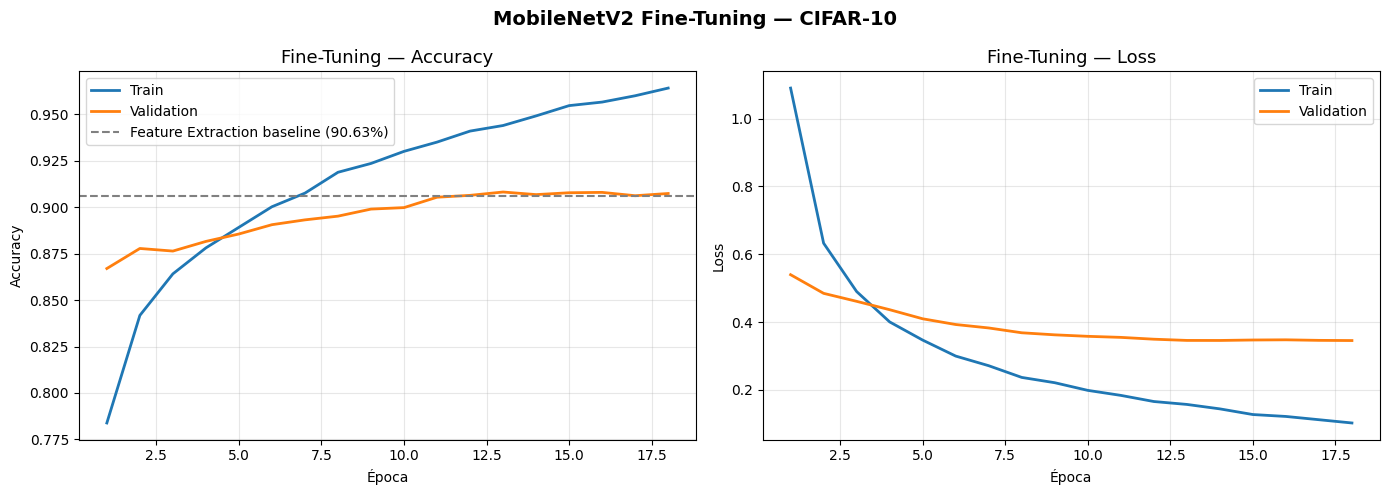

Figura guardada ✓


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history_ft.history["accuracy"]) + 1)

# --- Accuracy ---
axes[0].plot(epochs_range, history_ft.history["accuracy"],
             label="Train", linewidth=2)
axes[0].plot(epochs_range, history_ft.history["val_accuracy"],
             label="Validation", linewidth=2)
axes[0].axhline(y=acc_fe, color="gray", linestyle="--",
                linewidth=1.5, label=f"Feature Extraction baseline ({acc_fe:.2%})")
axes[0].set_title("Fine-Tuning — Accuracy", fontsize=13)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Loss ---
axes[1].plot(epochs_range, history_ft.history["loss"],
             label="Train", linewidth=2)
axes[1].plot(epochs_range, history_ft.history["val_loss"],
             label="Validation", linewidth=2)
axes[1].set_title("Fine-Tuning — Loss", fontsize=13)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("MobileNetV2 Fine-Tuning — CIFAR-10", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/11_finetuning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada ✓")

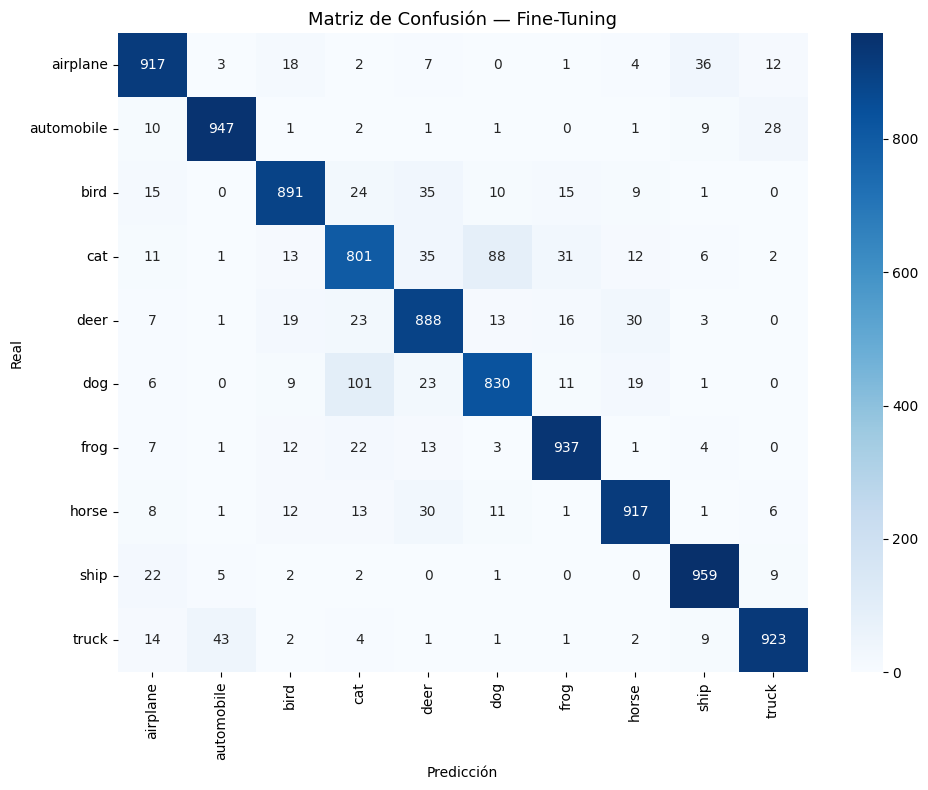


Reporte por clase:
              precision    recall  f1-score   support

    airplane       0.90      0.92      0.91      1000
  automobile       0.95      0.95      0.95      1000
        bird       0.91      0.89      0.90      1000
         cat       0.81      0.80      0.80      1000
        deer       0.86      0.89      0.87      1000
         dog       0.87      0.83      0.85      1000
        frog       0.92      0.94      0.93      1000
       horse       0.92      0.92      0.92      1000
        ship       0.93      0.96      0.95      1000
       truck       0.94      0.92      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [25]:
# Predicciones sobre test set
y_pred_probs = model_ft.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for _, y in test_ds], axis=0).flatten()

# Matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_title("Matriz de Confusión — Fine-Tuning", fontsize=13)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("../figures/11_confusion_matrix_finetuning.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nReporte por clase:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [26]:
print("=" * 50)
print("   RESUMEN FINAL — Notebook 11")
print("=" * 50)
print(f"  Feature Extraction:  86.5%")
print(f"  Fine-Tuning:         90.0%  (+3.5%)")
print("=" * 50)
print()
print("Clases más difíciles:")
print("  cat  → 80% f1  (confundido con dog/deer)")
print("  dog  → 85% f1  (confundido con cat)")
print()
print("Clases mejor clasificadas:")
print("  automobile → 95% f1")
print("  ship       → 95% f1")
print("  frog       → 93% f1")

   RESUMEN FINAL — Notebook 11
  Feature Extraction:  86.5%
  Fine-Tuning:         90.0%  (+3.5%)

Clases más difíciles:
  cat  → 80% f1  (confundido con dog/deer)
  dog  → 85% f1  (confundido con cat)

Clases mejor clasificadas:
  automobile → 95% f1
  ship       → 95% f1
  frog       → 93% f1


In [27]:
"""
## Conclusiones

### Resultados
| Estrategia         | Test Accuracy | Δ       |
|--------------------|---------------|---------|
| Feature Extraction | 86.5%         | —       |
| Fine-Tuning        | 90.0%         | +3.5%   |

### ¿Cuándo usar cada estrategia?

"Feature Extraction"
- Dataset pequeño (< 5k imágenes)
- Dominio muy diferente a ImageNet
- Recursos computacionales limitados
- Entrenamiento rápido como baseline

"Fine-Tuning"
- Dataset mediano/grande (> 10k imágenes)
- Dominio similar a ImageNet
- Se busca el máximo accuracy posible
- Se dispone de GPU y tiempo de cómputo

### Observaciones
- "cat" y "dog" siguen siendo las clases más difíciles — 
  son visualmente similares y CIFAR-10 tiene imágenes de 32×32
  donde los detalles discriminativos se pierden incluso con upscaling.
- El fine-tuning adaptó las capas superiores de MobileNetV2
  a las texturas y formas específicas de CIFAR-10.
- Un LR de "1e-5" fue suficiente para mejorar sin destruir
  los pesos preentrenados.

### Próximo notebook
"12_" — Visualización de features: "Grad-CAM" para entender
qué regiones de la imagen activan las predicciones del modelo.
"""

'\n## Conclusiones\n\n### Resultados\n| Estrategia         | Test Accuracy | Δ       |\n|--------------------|---------------|---------|\n| Feature Extraction | 86.5%         | —       |\n| Fine-Tuning        | 90.0%         | +3.5%   |\n\n### ¿Cuándo usar cada estrategia?\n\n"Feature Extraction"\n- Dataset pequeño (< 5k imágenes)\n- Dominio muy diferente a ImageNet\n- Recursos computacionales limitados\n- Entrenamiento rápido como baseline\n\n"Fine-Tuning"\n- Dataset mediano/grande (> 10k imágenes)\n- Dominio similar a ImageNet\n- Se busca el máximo accuracy posible\n- Se dispone de GPU y tiempo de cómputo\n\n### Observaciones\n- "cat" y "dog" siguen siendo las clases más difíciles — \n  son visualmente similares y CIFAR-10 tiene imágenes de 32×32\n  donde los detalles discriminativos se pierden incluso con upscaling.\n- El fine-tuning adaptó las capas superiores de MobileNetV2\n  a las texturas y formas específicas de CIFAR-10.\n- Un LR de "1e-5" fue suficiente para mejorar sin destr